In [ ]:
from models.black_scholes import *
from fetch_market_data import *

In [4]:
ticker = "AMZN"

spot = MarketData(ticker).getSpot()

In [5]:
apple = MarketData(ticker)
S_0, X, r, sigma, T = apple.getOptionValues(call=True, strike_index=1)

{'S0': 224.2100067138672, 'X': 125.0, 'r': 0.03763000011444092, 'sigma': 1.5703146484375, 'T': 0.023809523809523808}


In [6]:
apple = MarketData(ticker)
apple.plotStockPrice()

/Users/samgrant/Desktop/Fin_Math/monte_carlo.py:78: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



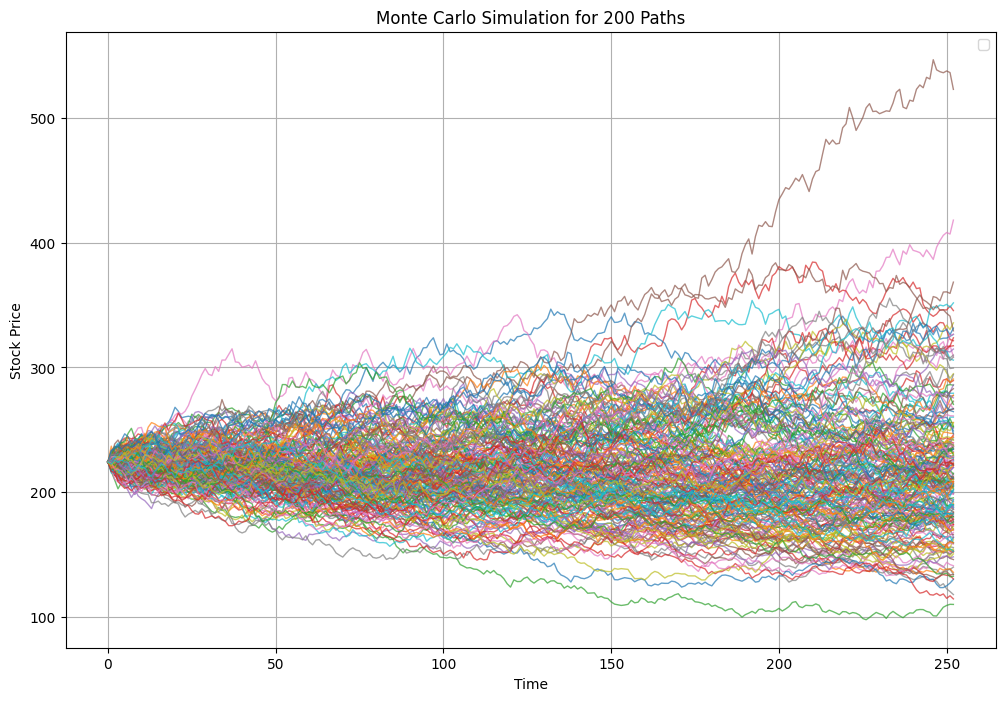

In [ ]:
from engines.monte_carlo import *
mc = MonteCarloPricing(S_0=S_0, X=X, r=r, sigma=sigma, T=T, num_paths=1000, steps=252)

mc.plot_paths(num_plots=200)

In [44]:
price_american, stderr_american = mc.american(call=False, antithetic=True)
print("American Put Price: ", price_american)

American Put Price:  0.0


In [45]:
import yfinance as yf

ticker = "AMZN"
stock = yf.Ticker(ticker)

# Pick an expiry
expiries = stock.options
print("Available expiries:", expiries)

expiry = expiries[0]   # choose the nearest expiry
chain = stock.option_chain(expiry)

# Look at calls and puts
print("\nCalls:")
print(chain.calls[['strike', 'impliedVolatility']].head(15))

print("\nPuts:")
print(chain.puts[['strike', 'impliedVolatility']].head(15))


Available expiries: ('2025-10-17', '2025-10-24', '2025-10-31', '2025-11-07', '2025-11-14', '2025-11-21', '2025-11-28', '2025-12-19', '2026-01-16', '2026-02-20', '2026-03-20', '2026-04-17', '2026-05-15', '2026-06-18', '2026-08-21', '2026-09-18', '2026-12-18', '2027-01-15', '2027-06-17', '2027-12-17', '2028-01-21')

Calls:
    strike  impliedVolatility
0     85.0           6.578127
1     90.0           6.394533
2     95.0           6.072268
3    100.0           5.566409
4    105.0           5.525394
5    110.0           5.158207
6    115.0           4.572270
7    120.0           4.498051
8    125.0           4.177739
9    130.0           4.013677
10   135.0           3.824219
11   140.0           3.687501
12   145.0           3.085940
13   150.0           2.355473
14   155.0           2.886722

Puts:
    strike  impliedVolatility
0     85.0           3.875000
1     90.0           3.625001
2     95.0           3.375002
3    100.0           3.250002
4    105.0           3.000002
5    110.0

In [9]:
price, stderr = mc.european(call=True)
print("European Call Price: ", price)

European Call Price:  153.3061967927449


In [ ]:
from models.binomial_method import *
bm = BinomialPricing(S_0=S_0, K=X, r=r, sigma=sigma, T=T, steps=100)
price_binomial = bm.european(call=True)
print("Binomial European Call Price: ", price_binomial)

Binomial European Call Price:  153.30453620204767


In [18]:
from sensitivities_demo import run_pricer_and_sensitivities

test_results = run_pricer_and_sensitivities(S_0=100, strike=100, r=0.05, sigma=0.2, T=1, num_paths=10000, steps=252, call=True)
test_results

{'price': '10.5472',
 'price_stderr': np.float64(0.14790537807882356),
 'delta': '0.6367',
 'delta_stderr': np.float64(0.00576543884105168),
 'vega': '37.5547',
 'vega_stderr': np.float64(0.7611329489321698)}